In [1]:
library(asreml)
library(data.table)
library(tidyverse)
library(parallel)
library(qqman)
library(topGO)
library(pheatmap)
library(asremlPlus)
library(ggplot2)
library(ggridges)
library(ape)
library(ggtree)
library(geiger)
library(taxize)
library(xgboost)
library(PRROC)

Loading required package: Matrix



Online License checked out Wed Feb 19 15:20:29 2025


Loading ASReml-R version 4.2


── Attaching core tidyverse packages ───────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ─────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::between()     masks data.table::between()
✖ tidyr::expand()      masks Matrix::expand()
✖ dplyr::filter()      masks stats::filter()
✖ dplyr::first()       masks data.table::first()
✖ lubridate::hour()    masks data.table::hour()
✖ lubridate::isoweek() masks data.table::isoweek()
✖ dplyr::lag()         masks stats::lag()
✖ dplyr::last()        masks data.table::last()
✖ lubridate::mday()    masks data.table::mday()
✖ lubridate::minute()  masks data.table::minute()
✖ lubridate::month()   masks data.table::month()
✖ tidyr::pack()        masks Matrix::pack()
✖ lubridate

In [2]:
metadata = read.csv("/workdir/sh2246/p_phyloGWAS/data/Poaceae_metadata_2024.08.21.csv",header = T)

In [3]:
phyloKMat <- read.table('/workdir/sh2246/p_phyloGWAS/data/phyloK_800Poaceae_astral.txt')
colnames(phyloKMat) <- rownames(phyloKMat)

In [4]:
TABASCO = read.csv("/workdir/sh2246/p_phyloGWAS/data/tabasco_Poaceae800.csv")
TABASCO = merge(TABASCO,metadata[,c(1,9)],by = "assemblyID",all.x = T)
TABASCO = TABASCO[!duplicated(TABASCO[,1]),]
rownames(TABASCO) = TABASCO$assemblyID

In [5]:
envData = read.table("/workdir/sh2246/p_phyloGWAS/output/envData_759Poaceae_20240821.txt")

In [6]:
envDf = cbind(rownames(envData),envData)
colnames(envDf)[1] = "assemblyID"
envDf$assemblyID = as.factor(envDf$assemblyID)

In [7]:
# load tree
spTre = read.tree("/workdir/sh2246/p_phyloGWAS/output/PoaceaeTree_angiosperm353_astral.nwk")
spTre.rooted = root(spTre,"ASM1935983v1")
spTre.rooted$edge.length[is.na(spTre.rooted$edge.length)] = 0.1
commonID = intersect(spTre.rooted$tip.label,rownames(envDf))

In [8]:
taxanomicGroup = read.csv("/workdir/sh2246/p_phyloGWAS/data/Poaceae_taxonomic_groups_subtribeAdded_SKH20250210.csv",header = T)

In [9]:
taxanomicGroup = taxanomicGroup[!duplicated(taxanomicGroup$assemblyID),]
rownames(taxanomicGroup) = taxanomicGroup$assemblyID

In [10]:
library(Biostrings)

Loading required package: XVector


Attaching package: ‘XVector’


The following object is masked from ‘package:purrr’:

    compact


Loading required package: GenomeInfoDb


Attaching package: ‘Biostrings’


The following object is masked from ‘package:ape’:

    complement


The following object is masked from ‘package:graph’:

    complement


The following object is masked from ‘package:base’:

    strsplit




In [11]:
aaFasta = mclapply(list.files("/workdir/sh2246/p_phyloGWAS/output/aminoAcidPerTaxa/",pattern = "*.fa",full.names = T),function(x) readAAStringSet(x),mc.cores = 30)

In [12]:
aa.comp = mclapply(aaFasta,function(x){
    tmp = letterFrequency(x,letters = AA_STANDARD)
    return(colSums(tmp)/sum(tmp))
},mc.cores = 30)


In [13]:
aa.comp = Reduce("rbind",aa.comp)

In [14]:
rownames(aa.comp) = gsub(".fa","",list.files("/workdir/sh2246/p_phyloGWAS/output/aminoAcidPerTaxa/",pattern = "*.fa"))

In [15]:
head(aa.comp)

,A,R,N,D,C,Q,E,G,H,I,L,K,M,F,P,S,T,W,Y,V
10wheat_assembly_jagger,0.09358459,0.06168811,0.03437020,0.05452571,0.01842727,0.03484510,0.06032271,0.07355779,0.02420659,0.04344265,0.09651017,0.05014169,0.02422943,0.03727672,0.05495606,0.08261782,0.04746970,0.01286154,0.02627193,0.06869420
10wheat_assembly_lancer,0.09352186,0.06161018,0.03440222,0.05460932,0.01840498,0.03485382,0.06033932,0.07350617,0.02417510,0.04347088,0.09654754,0.05013867,0.02419096,0.03724372,0.05514760,0.08267447,0.04750199,0.01281295,0.02627161,0.06857665
10wheat_assembly_stanley,0.09353504,0.06156762,0.03439946,0.05456995,0.01841748,0.03485913,0.06026844,0.07343916,0.02420541,0.04344249,0.09661186,0.05016545,0.02419320,0.03725758,0.05514173,0.08268932,0.04751708,0.01282638,0.02626943,0.06862380
4AgS,0.08848574,0.06643057,0.03506031,0.04964002,0.02177204,0.03298351,0.05382026,0.08010679,0.02569193,0.04357932,0.09887662,0.04518697,0.02402241,0.03676076,0.05984143,0.07980992,0.04905530,0.01480140,0.02681626,0.06725846
A1010002,0.09460555,0.06279573,0.03435236,0.05393437,0.01967899,0.03463769,0.05788267,0.07420006,0.02469784,0.04303625,0.09593862,0.04849215,0.02325175,0.03731767,0.05527200,0.08193097,0.04858765,0.01341403,0.02648415,0.06948949
A1014002,0.09608304,0.06306011,0.03418486,0.05432913,0.01892547,0.03490417,0.05940244,0.07357404,0.02445006,0.04244113,0.09602489,0.04889692,0.02308795,0.03661249,0.05629636,0.08307326,0.04752108,0.01293848,0.02592161,0.06827248


In [16]:
henryDat = read.csv("/workdir/sh2246/p_phyloGWAS/data/Henry_processed_data.csv",header = T)

In [17]:
dim(henryDat)

[1] 12376    36

In [18]:
AA_ALPHABET

[1] "A" "R" "N" "D" "C" "Q" "E" "G" "H" "I" "L" "K" "M" "F" "P" "S" "T" "W" "Y"
[20] "V" "U" "O" "B" "J" "Z" "X" "*" "-" "+" "."

In [19]:
head(henryDat)

,Path,GC_Content,genomeLength,Total_Amino_Acids,M,T,A,I,L,E,⋯,LUI,Species,Organism,occurence_query_term,num_occurrences,occurrence_centroid_x,occurrence_centroid_y,occurrence_range_x,occurrence_range_y,occurrence_hull_area
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,data/gbfs/NC0081151Eucalyptusglobulus.gbf.fixed,0.3685288,160286,25453,0.02341571,0.05119239,0.05256748,0.08686599,0.1054100,0.05272463,⋯,NC0081151Eucalyptusglobulus,Eucalyptus globulus,Eucalyptus globulus subsp globulus,Eucalyptus globulus subsp globulus,361,53.916699,8.128085,186.17143,85.09339,2033.8989
2,data/gbfs/NC0081161Staurastrumpunctulatum.gbf.fixed,0.3248668,157089,9979,0.02425093,0.05301132,0.07646057,0.07315362,0.1069245,0.05010522,⋯,NC0081161Staurastrumpunctulatum,Staurastrum punctulatum,Staurastrum punctulatum,Staurastrum punctulatum,168,7.429715,48.527423,231.19680,36.49963,4272.6861
3,data/gbfs/NC0071441Cucumissativus.gbf.fixed,0.3707894,155293,19560,0.02443763,0.05378323,0.06201431,0.08773006,0.1049591,0.05005112,⋯,NC0071441Cucumissativus,Cucumis sativus,Cucumis sativus,Cucumis sativus,524,-16.852110,37.987933,297.42353,108.45749,23550.8103
4,data/gbfs/NC0068611Huperzialucidula.gbf.fixed,0.3624662,154373,21604,0.02207924,0.05249028,0.06184040,0.08160526,0.1020181,0.05401777,⋯,NC0068611Huperzialucidula,Huperzia lucidula,Huperzia lucidula,Huperzia lucidula,2972,-78.674543,42.821909,45.73944,19.90533,648.7108
5,data/gbfs/NC0009321Arabidopsisthaliana.gbf.fixed,0.3629384,154478,26541,0.02283260,0.05131683,0.05218341,0.08699748,0.1063637,0.05282393,⋯,NC0009321Arabidopsisthaliana,Arabidopsis thaliana,Arabidopsis thaliana,Arabidopsis thaliana,5937,15.500365,48.998690,266.51487,71.69183,10950.0322
6,data/gbfs/NC0013191Marchantiapaleacea.gbf.fixed,0.2880834,121024,20218,0.02176279,0.05030171,0.05816599,0.09491542,0.1110891,0.05020279,⋯,NC0013191Marchantiapaleacea,Marchantia paleacea,Marchantia paleacea,Marchantia paleacea,451,37.695251,35.257983,262.02671,53.80498,10074.2503


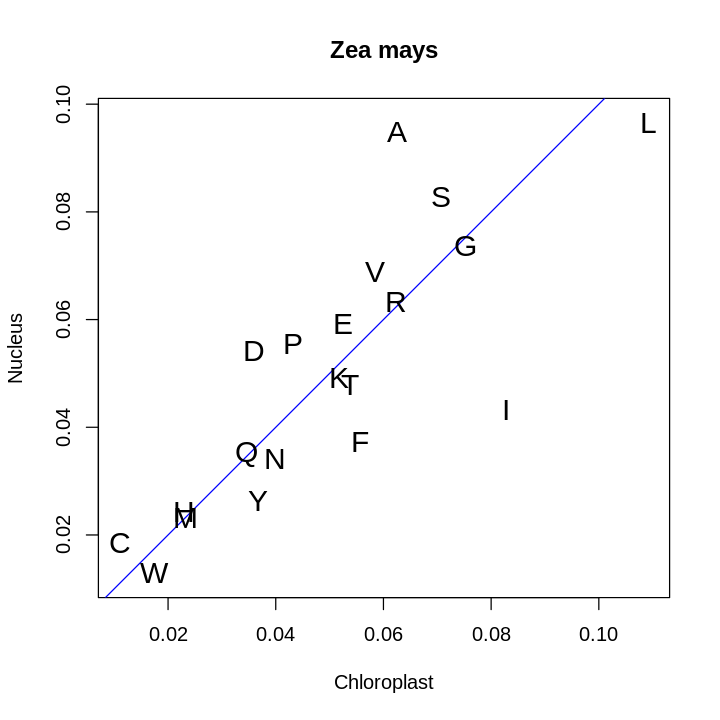

In [20]:
options(repr.plot.width=6, repr.plot.height=6)
plot(unlist(henryDat[grep("Zea",henryDat$Path),AA_ALPHABET[1:20]]),as.vector(aa.comp[788,]),
     xlab = "Chloroplast",ylab = "Nucleus",pch = "",asp= 1, main = "Zea mays")
abline(a= 0, b= 1,col = "blue")
text(unlist(henryDat[grep("Zea",henryDat$Path),AA_STANDARD]),as.vector(aa.comp[788,]),AA_STANDARD,cex = 1.5)
# plot(sort(unlist(henryDat[grep("Zea",henryDat$Path),AA_ALPHABET[1:20]])),sort(as.vector(aa.comp[788,])))
# abline(a= 0, b= 1)

In [54]:
#photosynthetic genes from Jonathan
photoGene = read.table("/workdir/sh2246/p_phyloGWAS/output/photo_gene_OG_20250225.txt",header = F)[,1]

In [47]:
aaFastaPerOG = mclapply(list.files("/workdir/sh2246/p_phyloGWAS/output/orthofinderProteinMSAs/",pattern = "*.fa",
                                   full.names = T),function(x) readAAStringSet(x),mc.cores = 30)

In [59]:
names(aaFastaPerOG) = gsub(".fa","",list.files("/workdir/sh2246/p_phyloGWAS/output/orthofinderProteinMSAs/",pattern = "*.fa"))

In [61]:
randomOG = sample(setdiff(names(aaFastaPerOG),photoGene),length(photoGene))

In [64]:
aa.comp.og.photo = mclapply(aaFastaPerOG[intersect(photoGene,names(aaFastaPerOG))],function(x){
    tmp = letterFrequency(x,letters = AA_STANDARD)
    rownames(tmp) = names(x)
    return(tmp)
},mc.cores = 30)


aa.comp.og.photo = Reduce("rbind",aa.comp.og.photo)

aa.comp.photo = apply(aa.comp.og.photo,2,function(x) tapply(x,limma::strsplit2(rownames(aa.comp.og.photo),":")[,2],sum))

aa.comp.photo = aa.comp.photo/rowSums(aa.comp.photo)

In [75]:
aa.comp.og.random = mclapply(aaFastaPerOG[randomOG],function(x){
    tmp = letterFrequency(x,letters = AA_STANDARD)
    rownames(tmp) = names(x)
    return(tmp)
},mc.cores = 30)


aa.comp.og.random = Reduce("rbind",aa.comp.og.random)

aa.comp.random = apply(aa.comp.og.random,2,function(x) tapply(x,limma::strsplit2(rownames(aa.comp.og.random),":")[,2],sum))

aa.comp.random = aa.comp.random/rowSums(aa.comp.random)

In [79]:
aa.comp.random

,A,R,N,D,C,Q,E,G,H,I,L,K,M,F,P,S,T,W,Y,V
10wheat_assembly_jagger,0.09661421,0.06296826,0.03437715,0.05656758,0.02044190,0.03403804,0.05883537,0.07767710,0.02445822,0.03659196,0.09341387,0.05267843,0.02157580,0.03465268,0.05919568,0.08427913,0.04420071,0.01243046,0.02641869,0.06858475
10wheat_assembly_lancer,0.09637316,0.06327169,0.03396860,0.05699448,0.02064129,0.03394974,0.05914343,0.07774887,0.02419461,0.03683387,0.09372467,0.05383702,0.02114083,0.03383664,0.05911516,0.08499689,0.04368603,0.01218685,0.02620219,0.06815397
10wheat_assembly_stanley,0.09804129,0.06323476,0.03307487,0.05659669,0.02065496,0.03402728,0.05861697,0.07724203,0.02412791,0.03639390,0.09447213,0.05279664,0.02119370,0.03407539,0.05951167,0.08594847,0.04395552,0.01213130,0.02574414,0.06816039
4AgS,0.10061059,0.06670920,0.03572405,0.05313041,0.02105167,0.02724870,0.04957623,0.09085938,0.02032261,0.03663538,0.09231751,0.04037182,0.02086941,0.03344573,0.06807619,0.08329536,0.05057869,0.01394332,0.02679304,0.06844072
A1010002,0.09544366,0.06930605,0.03456432,0.05499542,0.02007628,0.03302682,0.05511369,0.07882676,0.02279649,0.03902901,0.09517755,0.04721918,0.02049023,0.03352946,0.06090890,0.08595251,0.04674610,0.01448804,0.02507318,0.06723633
A1014002,0.10145479,0.06917372,0.03354093,0.05303318,0.02217838,0.03356470,0.05602834,0.08155843,0.02460302,0.03663117,0.09237425,0.04659123,0.01970619,0.03415898,0.06232766,0.08436341,0.04433298,0.01207569,0.02602929,0.06627365
A1015002,0.09530089,0.06299292,0.03486927,0.05604443,0.01952679,0.03306875,0.05873253,0.07947658,0.02401542,0.03961149,0.09372860,0.05036391,0.02117516,0.03502143,0.05794639,0.08523318,0.04534273,0.01257830,0.02693176,0.06803946
A1020001,0.09544574,0.06231158,0.03458764,0.05579780,0.02086025,0.03318798,0.05792420,0.07821921,0.02347115,0.03991710,0.09514966,0.04909561,0.02018734,0.03542205,0.05897394,0.08726314,0.04691537,0.01283915,0.02648579,0.06594531
A1021002,0.09655229,0.06152708,0.03436746,0.05664876,0.02000658,0.03299715,0.05815611,0.07898487,0.02335014,0.03979390,0.09342798,0.05174304,0.02049989,0.03584740,0.05711467,0.08424688,0.04582328,0.01241504,0.02652927,0.06996821
A1025002,0.09746332,0.06305538,0.03329717,0.05251602,0.02169870,0.03280636,0.05633912,0.08139595,0.02361025,0.03727526,0.09537094,0.04910622,0.02035545,0.03386547,0.06049804,0.08684646,0.04672970,0.01239926,0.02621926,0.06915168


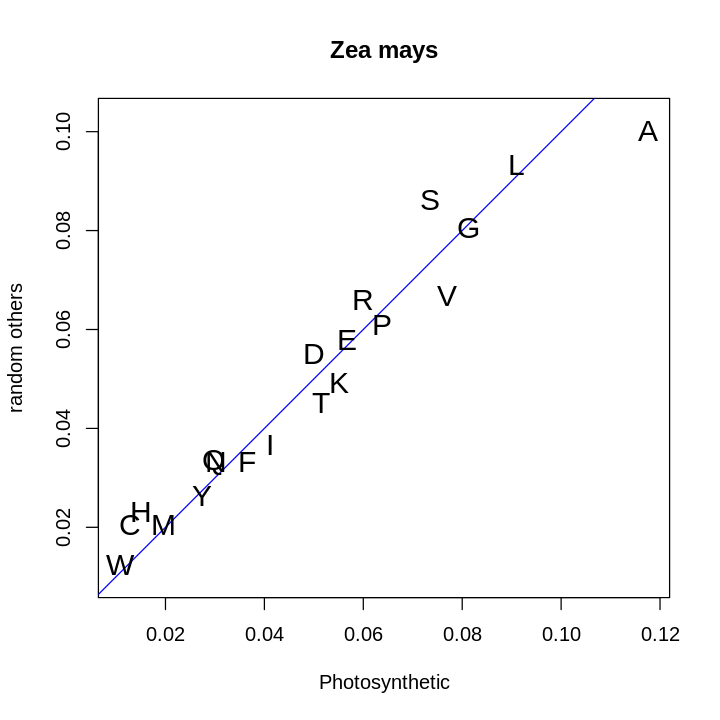

In [83]:
plot(as.vector(aa.comp.photo[760,]),as.vector(aa.comp.random[760,]),
     xlab = "Photosynthetic",ylab = "random others",pch = "",asp= 1, main = "Zea mays")
abline(a= 0, b= 1,col = "blue")
text(as.vector(aa.comp.photo[760,]),as.vector(aa.comp.random[760,]),AA_STANDARD,cex = 1.5)


In [ ]:
# Alanine	A	Ala	1
# Arginine	R	Arg	4
# Asparagine	N	Asn	2
# Aspartic Acid	D	Asp	1
# Cysteine	C	Cys	1
# Glutamine	Q	Gln	2
# Glutamic Acid	E	Glu	1
# Glycine	G	Gly	1
# Histidine	H	His	3
# Isoleucine	I	Ile	1
# Leucine	L	Leu	1
# Lysine	K	Lys	2
# Methionine	M	Met	1
# Phenylalanine	F	Phe	1
# Proline	P	Pro	1
# Serine	S	Ser	1
# Threonine	T	Thr	1
# Tryptophan	W	Trp	2
# Tyrosine	Y	Tyr	1
# Valine	V	Val	1

In [21]:
NInAA = c(1,4,2,1,1,2,1,1,3,1,1,2,1,1,1,1,1,2,1,1)
names(NInAA) = c("A","R","N","D","C","Q","E","G","H","I","L","K","M","F","P","S","T","W","Y","V")

In [22]:
NperAA = aa.comp%*%NInAA[colnames(aa.comp)]

In [23]:
names(NperAA) = rownames(aa.comp)

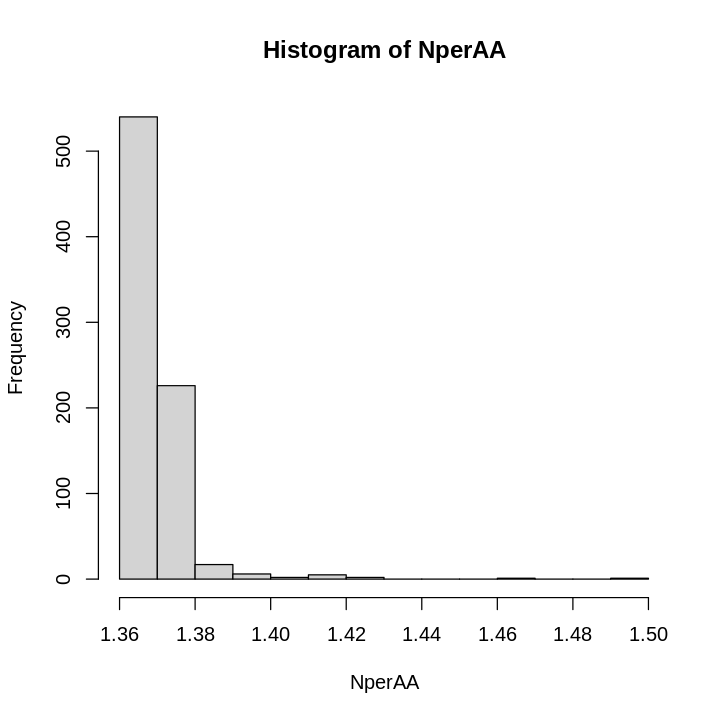

In [24]:
hist(NperAA)

In [25]:
head(sort(NperAA),10)
tail(sort(NperAA),10)

Oat_OT3098_v2                  Festuca_brevipila 
                          1.364396                           1.364430 
                       SRR14924115                      FRR_PoAnn_1.0 
                          1.364628                           1.364789 
                       SRR14867315   Avena_sativa_cv_Sang_v1_assembly 
                          1.364844                           1.364963 
Avena_insularis_BYU209_v1_assembly                       ASM2364667v1 
                          1.365020                           1.365225 
                      ASM2361440v1           10wheat_assembly_stanley 
                          1.365254                           1.365364

ASM155180v1           Cs-A1013-Draft-PanAnd-1.0 
                           1.408830                            1.410642 
Cs-KelloggPI219580-DRAFT-PanAnd-1.0                                Bruz 
                           1.411586                            1.411797 
                              PauV1                         ASM980554v1 
                           1.417545                            1.419106 
                        ASM155179v1           Hd-A1025-Draft-PanAnd-1.0 
                           1.420126                            1.427867 
         ChrysopogonNigritanus_v1.0                         SRR23951516 
                           1.463615                            1.492307

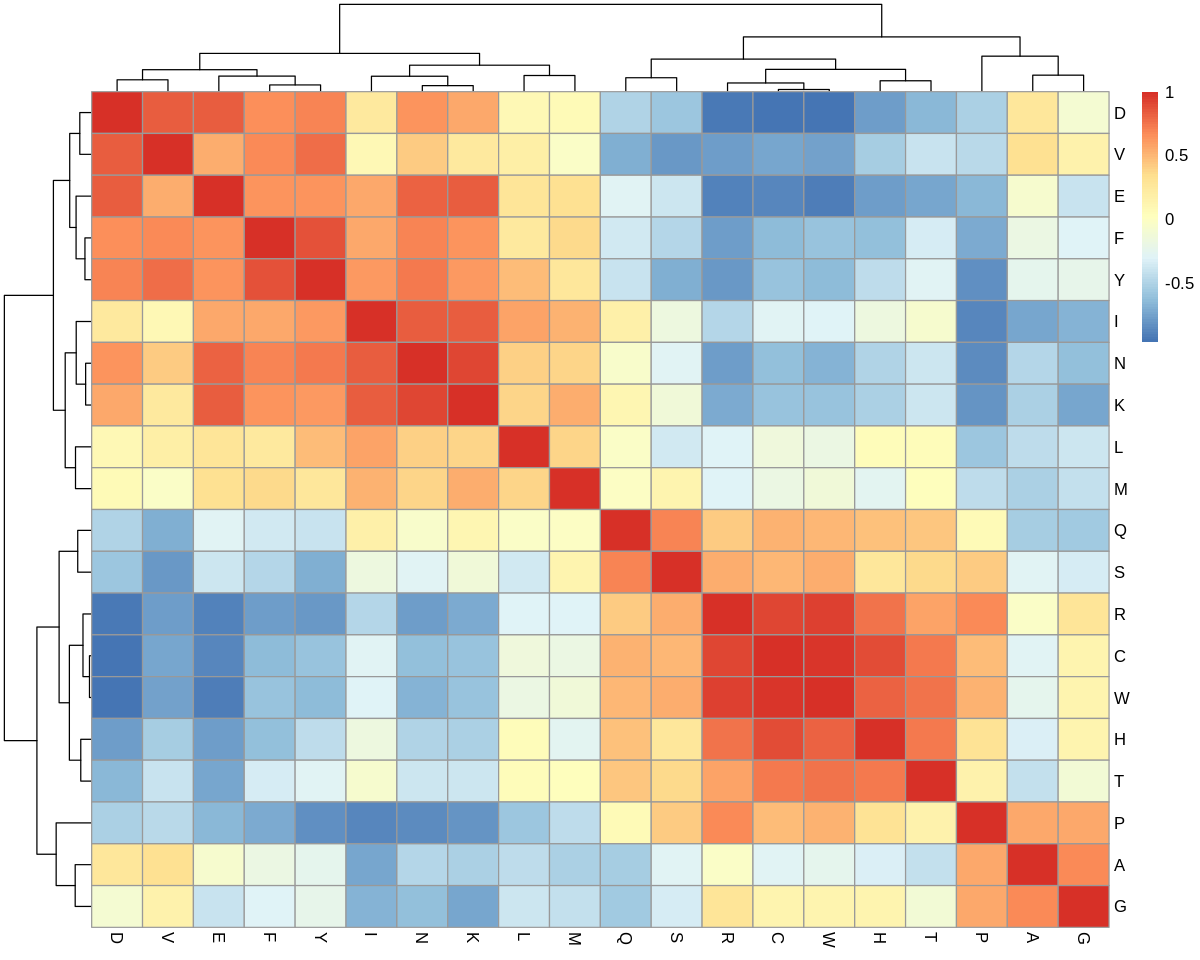

In [278]:
pheatmap(cor(aa.comp[commonID,]))

In [26]:
PCA.aa.comp = prcomp(aa.comp[commonID,])

[1] 0.9231931

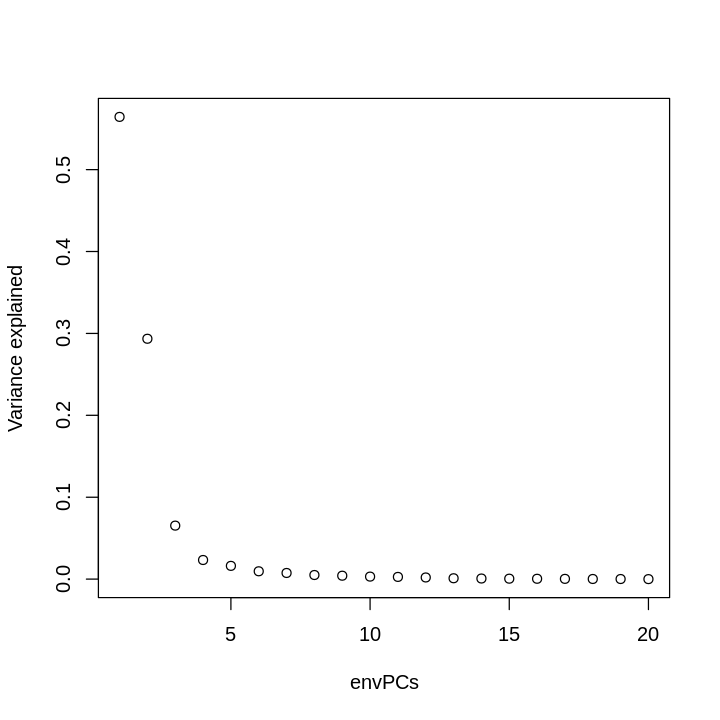

In [27]:
options(repr.plot.width=6, repr.plot.height=6)
plot(1:20,PCA.aa.comp$sdev^2/sum(PCA.aa.comp$sdev^2),xlab = "envPCs",ylab = "Variance explained")
sum((PCA.aa.comp$sdev^2/sum(PCA.aa.comp$sdev^2))[1:3])

In [37]:
table(taxanomicGroup[commonID,5])


     Alopecurinae    Andropogoninae     Anthephorinae    Anthistiriinae 
                2               157                 3                81 
        Apludinae     Aristaveninae     Arthraxoninae Arthrostylidiinae 
               21                 1                11                 1 
   Arundinariinae          Aveninae        Bambusinae     Boivinellinae 
               10                26                 4                10 
   Brachypodiinae          Brominae        Cenchrinae     Chionachninae 
                7                 3                12                 2 
  Chrysopogoninae      Coleanthinae      Dactylidinae   Dichantheliinae 
               16                 1                 2                 1 
      Eleusininae    Eragrostidinae      Germainiinae         Guaduinae 
               12                 4                 7                 2 
        Hordeinae    Hsuehochloinae       Ischaeminae          Loliinae 
               16                 1               

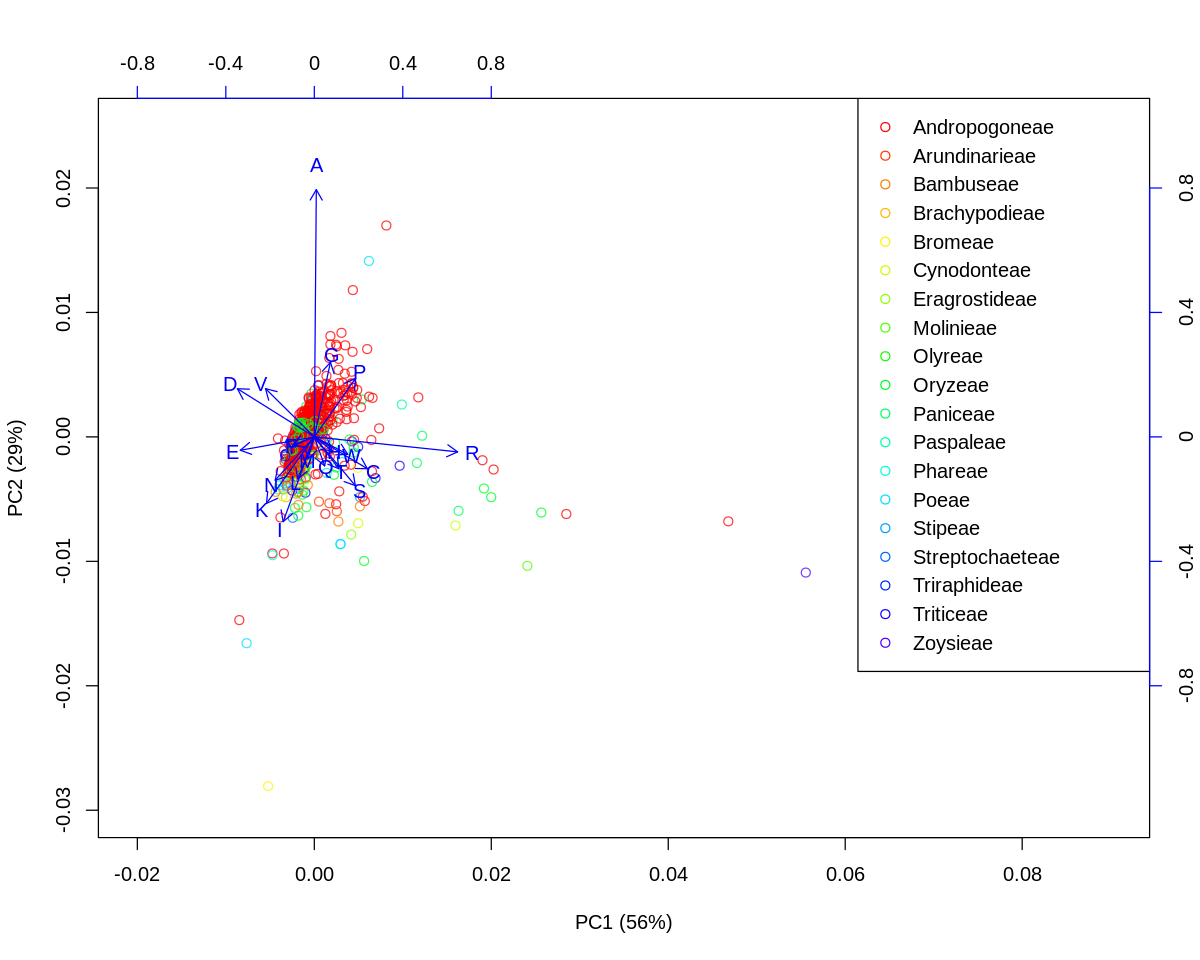

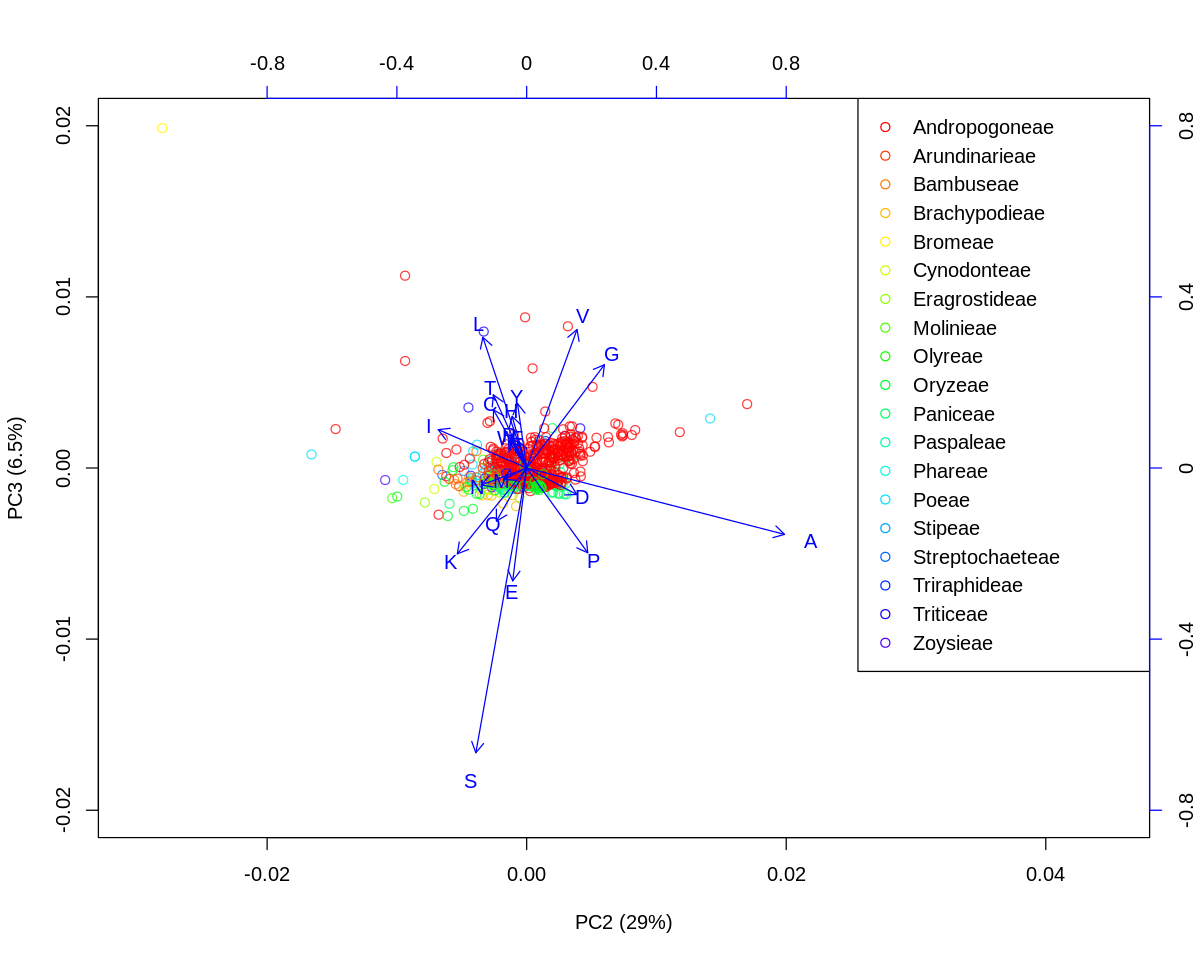

In [295]:
options(repr.plot.width=10, repr.plot.height=8)

plot(PCA.aa.comp$x,col = scales::alpha(rainbow(25)[as.factor(taxanomicGroup[commonID,5])],.75),
     xlim = c(-.02,.09),ylim = c(-0.03,0.025),xlab = "PC1 (56%)",ylab = "PC2 (29%)")
legend("topright",legend = levels(as.factor(taxanomicGroup[commonID,5])),col = rainbow(25)[1:19],pch = 1)
arrows(x0 = 0,y0 = 0,x1 = PCA.aa.comp$rotation[,1]/40,y1 = PCA.aa.comp$rotation[,2]/40,length = .1,col = "blue")
text(PCA.aa.comp$rotation[,1]/40*1.1,PCA.aa.comp$rotation[,2]/40*1.1,labels = rownames(PCA.aa.comp$rotation),col = "blue")
axis(3,at = seq(-0.02,0.02,0.01),labels = seq(-0.02,0.02,0.01)*40,col = "blue")
axis(4,at = seq(-0.02,0.02,0.01),labels = seq(-0.02,0.02,0.01)*40,col = "blue")

plot(PCA.aa.comp$x[,2:3],col = scales::alpha(rainbow(25)[as.factor(taxanomicGroup[commonID,5])],.75),
     xlim = c(-.03,.045),ylim = c(-0.02,0.02),xlab = "PC2 (29%)",ylab = "PC3 (6.5%)")
legend("topright",legend = levels(as.factor(taxanomicGroup[commonID,5])),col = rainbow(25)[1:19],pch = 1)
arrows(x0 = 0,y0 = 0,x1 = PCA.aa.comp$rotation[,2]/40,y1 = PCA.aa.comp$rotation[,3]/40,length = .1,col = "blue")
text(PCA.aa.comp$rotation[,2]/40*1.1,PCA.aa.comp$rotation[,3]/40*1.1,labels = rownames(PCA.aa.comp$rotation),col = "blue")
axis(3,at = seq(-0.02,0.02,0.01),labels = seq(-0.02,0.02,0.01)*40,col = "blue")
axis(4,at = seq(-0.02,0.02,0.01),labels = seq(-0.02,0.02,0.01)*40,col = "blue")

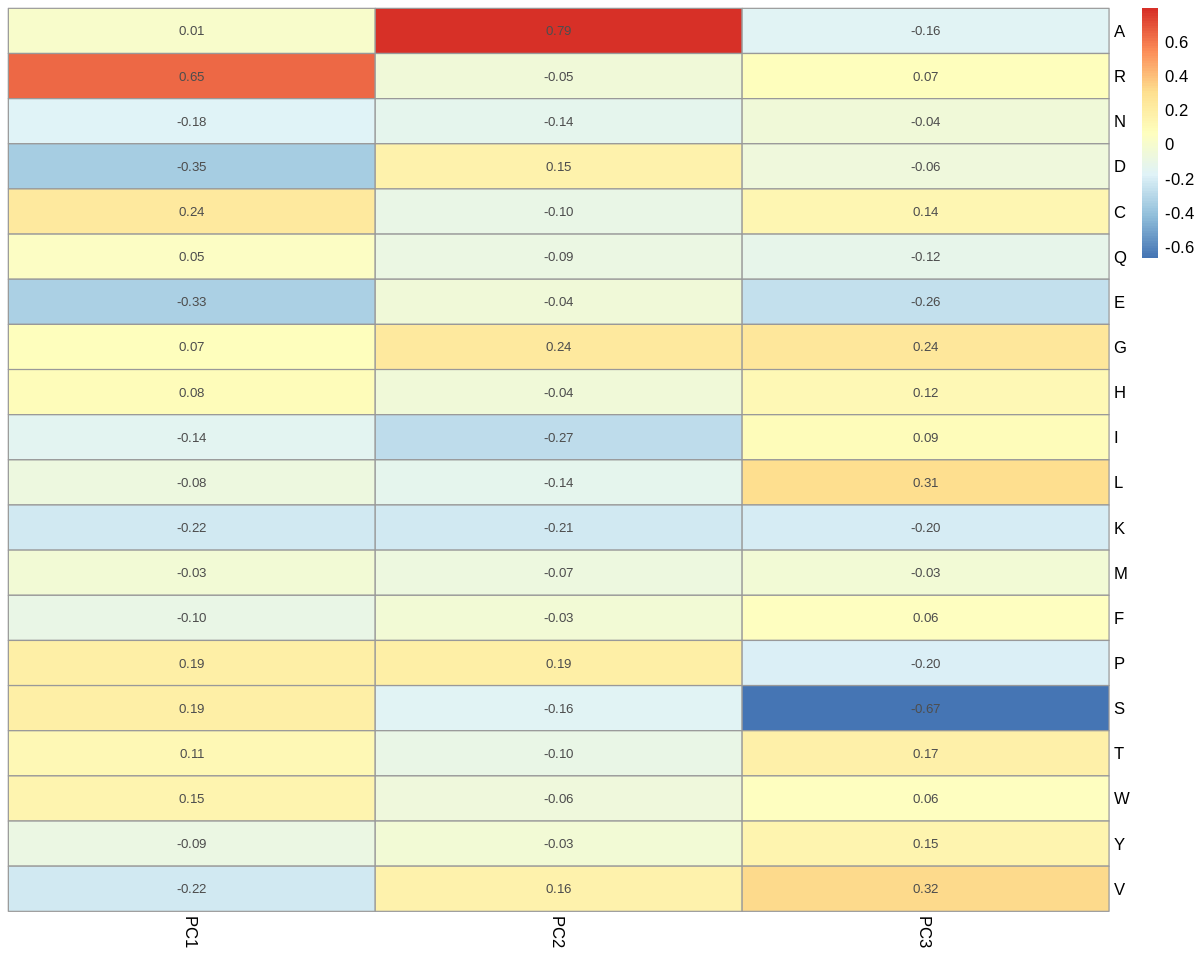

In [151]:
pheatmap::pheatmap(PCA.aa.comp$rotation[,1:3],cluster_rows = F,cluster_cols = F,display_numbers = T)

In [47]:
TABASCO[TABASCO$assemblyID%in%names(which(PCA.aa.comp$x[,1]>0.01)),]

,assemblyID,complete,duplicated,fraged,missing,technology
,<chr>,<int>,<int>,<int>,<int>,<chr>
AANG_UGA4,AANG_UGA4,3980,1191,382,39,Illumina HiSeq
ASM155179v1,ASM155179v1,4172,844,248,328,PacBio
ASM155180v1,ASM155180v1,4717,527,201,147,PacBio
ASM3043976v1,ASM3043976v1,99,153,374,4966,PacBio Sequel II
ASM3189477v1,ASM3189477v1,3834,1649,67,42,Oxford Nanopore PromethION
ASM980554v1,ASM980554v1,4037,826,535,194,Illumina HiSeq; PacBio RSII
Bruz,Bruz,4743,285,498,66,Illumina; PacBio
C_purpureuscv._Purple,C_purpureuscv._Purple,318,5250,14,10,Oxford Nanopore; Illumina
ChrysopogonNigritanus_v1.0,ChrysopogonNigritanus_v1.0,3676,1901,11,4,NA


In [43]:
taxanomicGroup[taxanomicGroup$assemblyID%in%names(which(PCA.aa.comp$x[,1]>0.01)),]

,assemblyID,Species,clade,subfamily,tribe,uid,subtribe
,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>
AANG_UGA4,AANG_UGA4,Alloteropsis angusta,PACMAD,Panicoideae,Paniceae,486853,Boivinellinae
C_purpureuscv._Purple,C_purpureuscv._Purple,Cenchrus purpureus,PACMAD,Panicoideae,Paniceae,154765,Cenchrinae
ASM3189477v1,ASM3189477v1,Chloris gayana,PACMAD,Chloridoideae,Cynodonteae,110876,Eleusininae
ChrysopogonNigritanus_v1.0,ChrysopogonNigritanus_v1.0,Chrysopogon nigritanus,PACMAD,Panicoideae,Andropogoneae,857534,Chrysopogoninae
Cs-A1013-Draft-PanAnd-1.0,Cs-A1013-Draft-PanAnd-1.0,Chrysopogon serrulatus,PACMAD,Panicoideae,Andropogoneae,330583,Chrysopogoninae
Cs-KelloggPI219580-DRAFT-PanAnd-1.0,Cs-KelloggPI219580-DRAFT-PanAnd-1.0,Chrysopogon serrulatus,PACMAD,Panicoideae,Andropogoneae,330583,Chrysopogoninae
Hd-A1025-Draft-PanAnd-1.0,Hd-A1025-Draft-PanAnd-1.0,Hyparrhenia diplandra,PACMAD,Panicoideae,Andropogoneae,798322,Andropogoninae
ASM980554v1,ASM980554v1,Oryza longistaminata,BOP,Oryzoideae,Oryzeae,4528,Oryzinae
ASM155179v1,ASM155179v1,Oryza meridionalis,BOP,Oryzoideae,Oryzeae,40149,Oryzinae


In [87]:
PCA.aa.comp.photo = prcomp(aa.comp.photo[intersect(commonID,rownames(aa.comp.photo)),])

[1] 5.982115e-01 1.822261e-01 7.598300e-02 3.932728e-02 2.205547e-02
 [6] 2.005310e-02 1.042352e-02 9.596186e-03 8.498535e-03 6.617954e-03
[11] 5.713535e-03 4.600805e-03 3.686730e-03 3.240007e-03 2.663880e-03
[16] 2.487626e-03 1.851758e-03 1.762017e-03 1.000975e-03 5.380653e-32

[1] 0.8564206

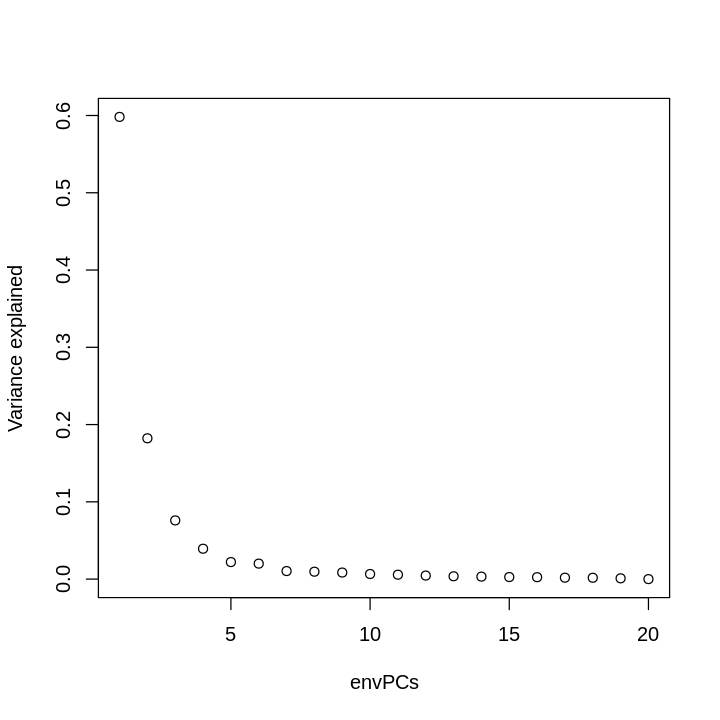

In [90]:
options(repr.plot.width=6, repr.plot.height=6)
plot(1:20,PCA.aa.comp.photo$sdev^2/sum(PCA.aa.comp.photo$sdev^2),xlab = "envPCs",ylab = "Variance explained")
PCA.aa.comp.photo$sdev^2/sum(PCA.aa.comp.photo$sdev^2)
sum((PCA.aa.comp.photo$sdev^2/sum(PCA.aa.comp.photo$sdev^2))[1:3])

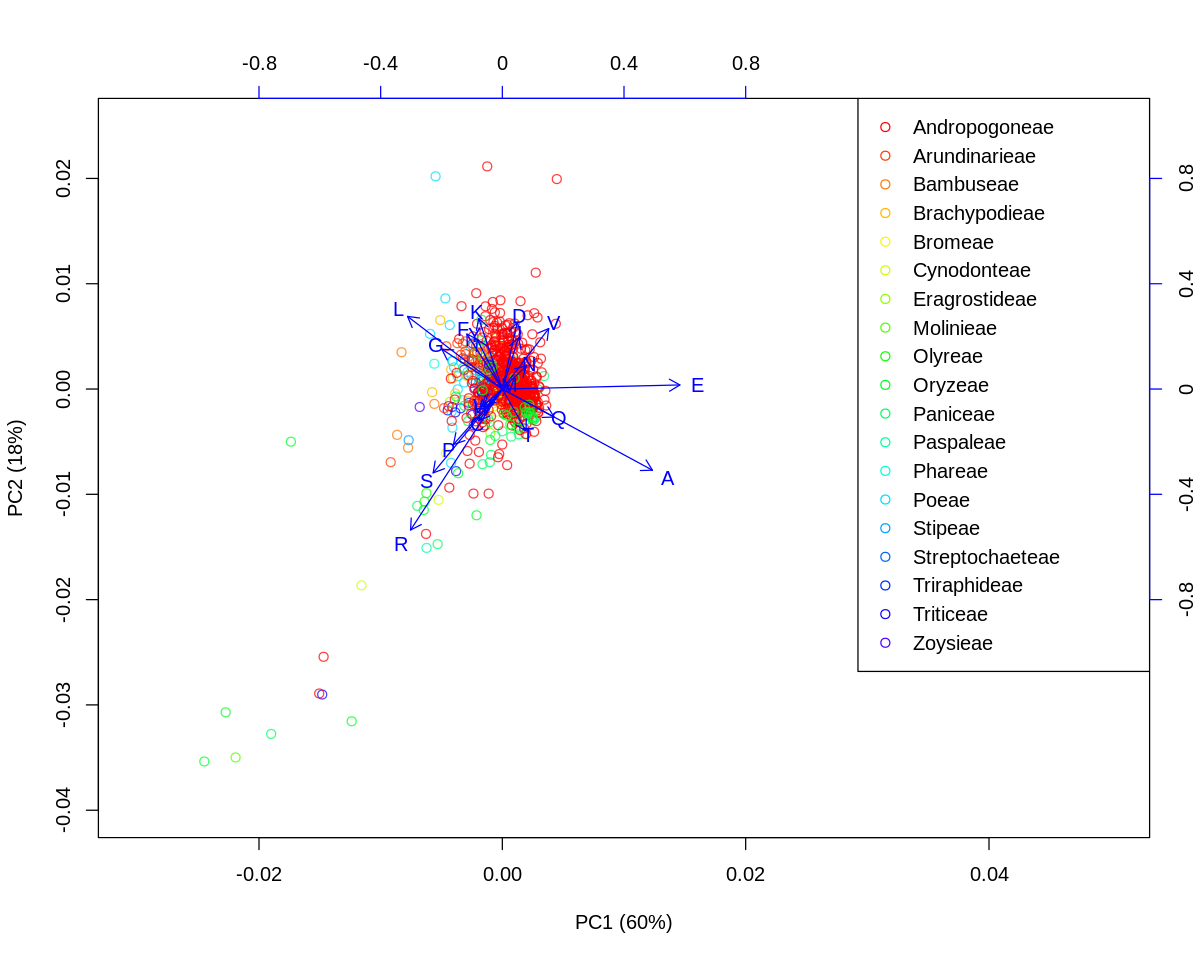

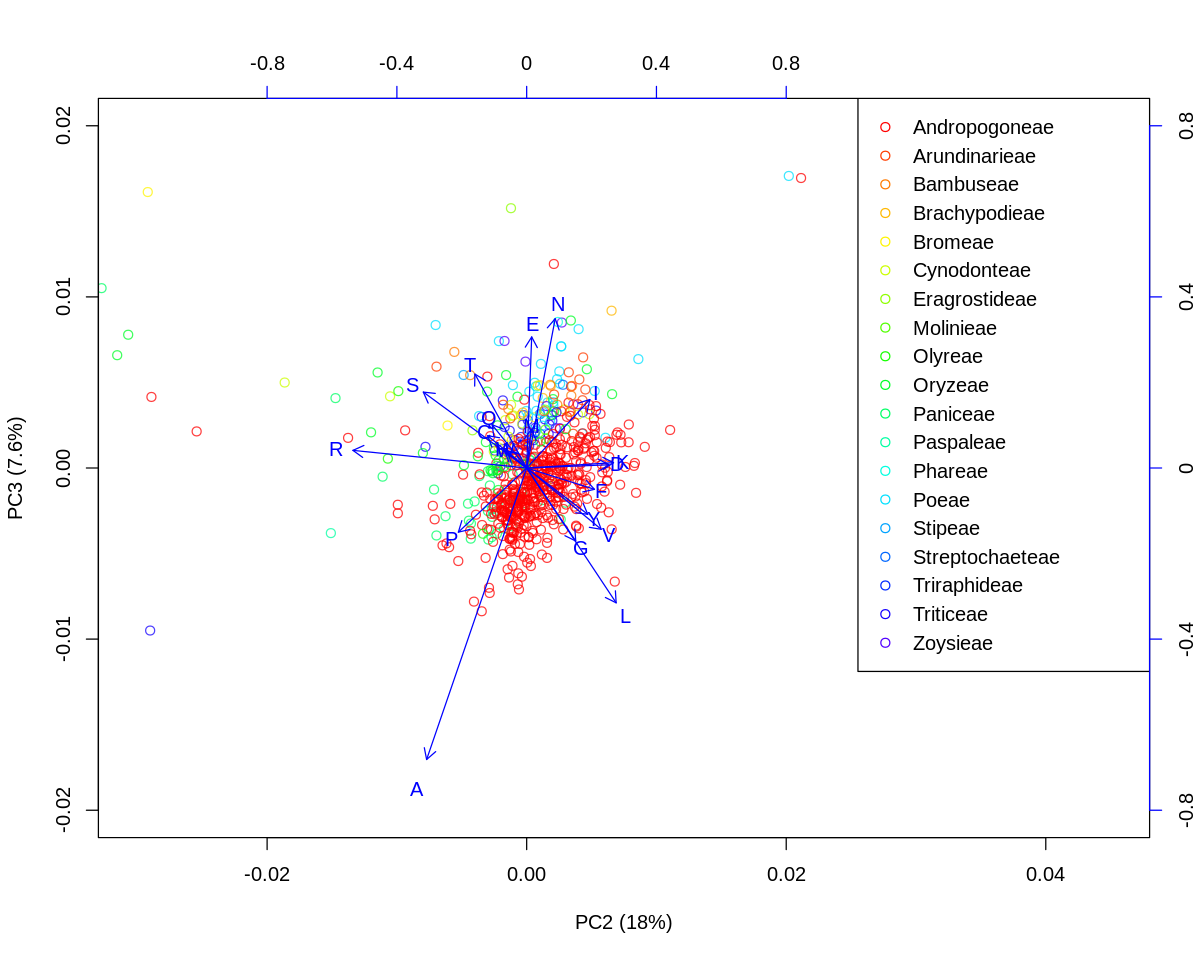

In [95]:
options(repr.plot.width=10, repr.plot.height=8)

plot(PCA.aa.comp.photo$x,col = scales::alpha(rainbow(25)[as.factor(taxanomicGroup[intersect(commonID,rownames(aa.comp.photo)),5])],.75),
     xlim = c(-.03,.05),ylim = c(-0.04,0.025),xlab = "PC1 (60%)",ylab = "PC2 (18%)")
legend("topright",legend = levels(as.factor(taxanomicGroup[intersect(commonID,rownames(aa.comp.photo)),5])),col = rainbow(25)[1:19],pch = 1)
arrows(x0 = 0,y0 = 0,x1 = PCA.aa.comp.photo$rotation[,1]/40,y1 = PCA.aa.comp.photo$rotation[,2]/40,length = .1,col = "blue")
text(PCA.aa.comp.photo$rotation[,1]/40*1.1,PCA.aa.comp.photo$rotation[,2]/40*1.1,labels = rownames(PCA.aa.comp.photo$rotation),col = "blue")
axis(3,at = seq(-0.02,0.02,0.01),labels = seq(-0.02,0.02,0.01)*40,col = "blue")
axis(4,at = seq(-0.02,0.02,0.01),labels = seq(-0.02,0.02,0.01)*40,col = "blue")

plot(PCA.aa.comp.photo$x[,2:3],col = scales::alpha(rainbow(25)[as.factor(taxanomicGroup[intersect(commonID,rownames(aa.comp.photo)),5])],.75),
     xlim = c(-.03,.045),ylim = c(-0.02,0.02),xlab = "PC2 (18%)",ylab = "PC3 (7.6%)")
legend("topright",legend = levels(as.factor(taxanomicGroup[intersect(commonID,rownames(aa.comp.photo)),5])),col = rainbow(25)[1:19],pch = 1)
arrows(x0 = 0,y0 = 0,x1 = PCA.aa.comp.photo$rotation[,2]/40,y1 = PCA.aa.comp.photo$rotation[,3]/40,length = .1,col = "blue")
text(PCA.aa.comp.photo$rotation[,2]/40*1.1,PCA.aa.comp.photo$rotation[,3]/40*1.1,labels = rownames(PCA.aa.comp.photo$rotation),col = "blue")
axis(3,at = seq(-0.02,0.02,0.01),labels = seq(-0.02,0.02,0.01)*40,col = "blue")
axis(4,at = seq(-0.02,0.02,0.01),labels = seq(-0.02,0.02,0.01)*40,col = "blue")

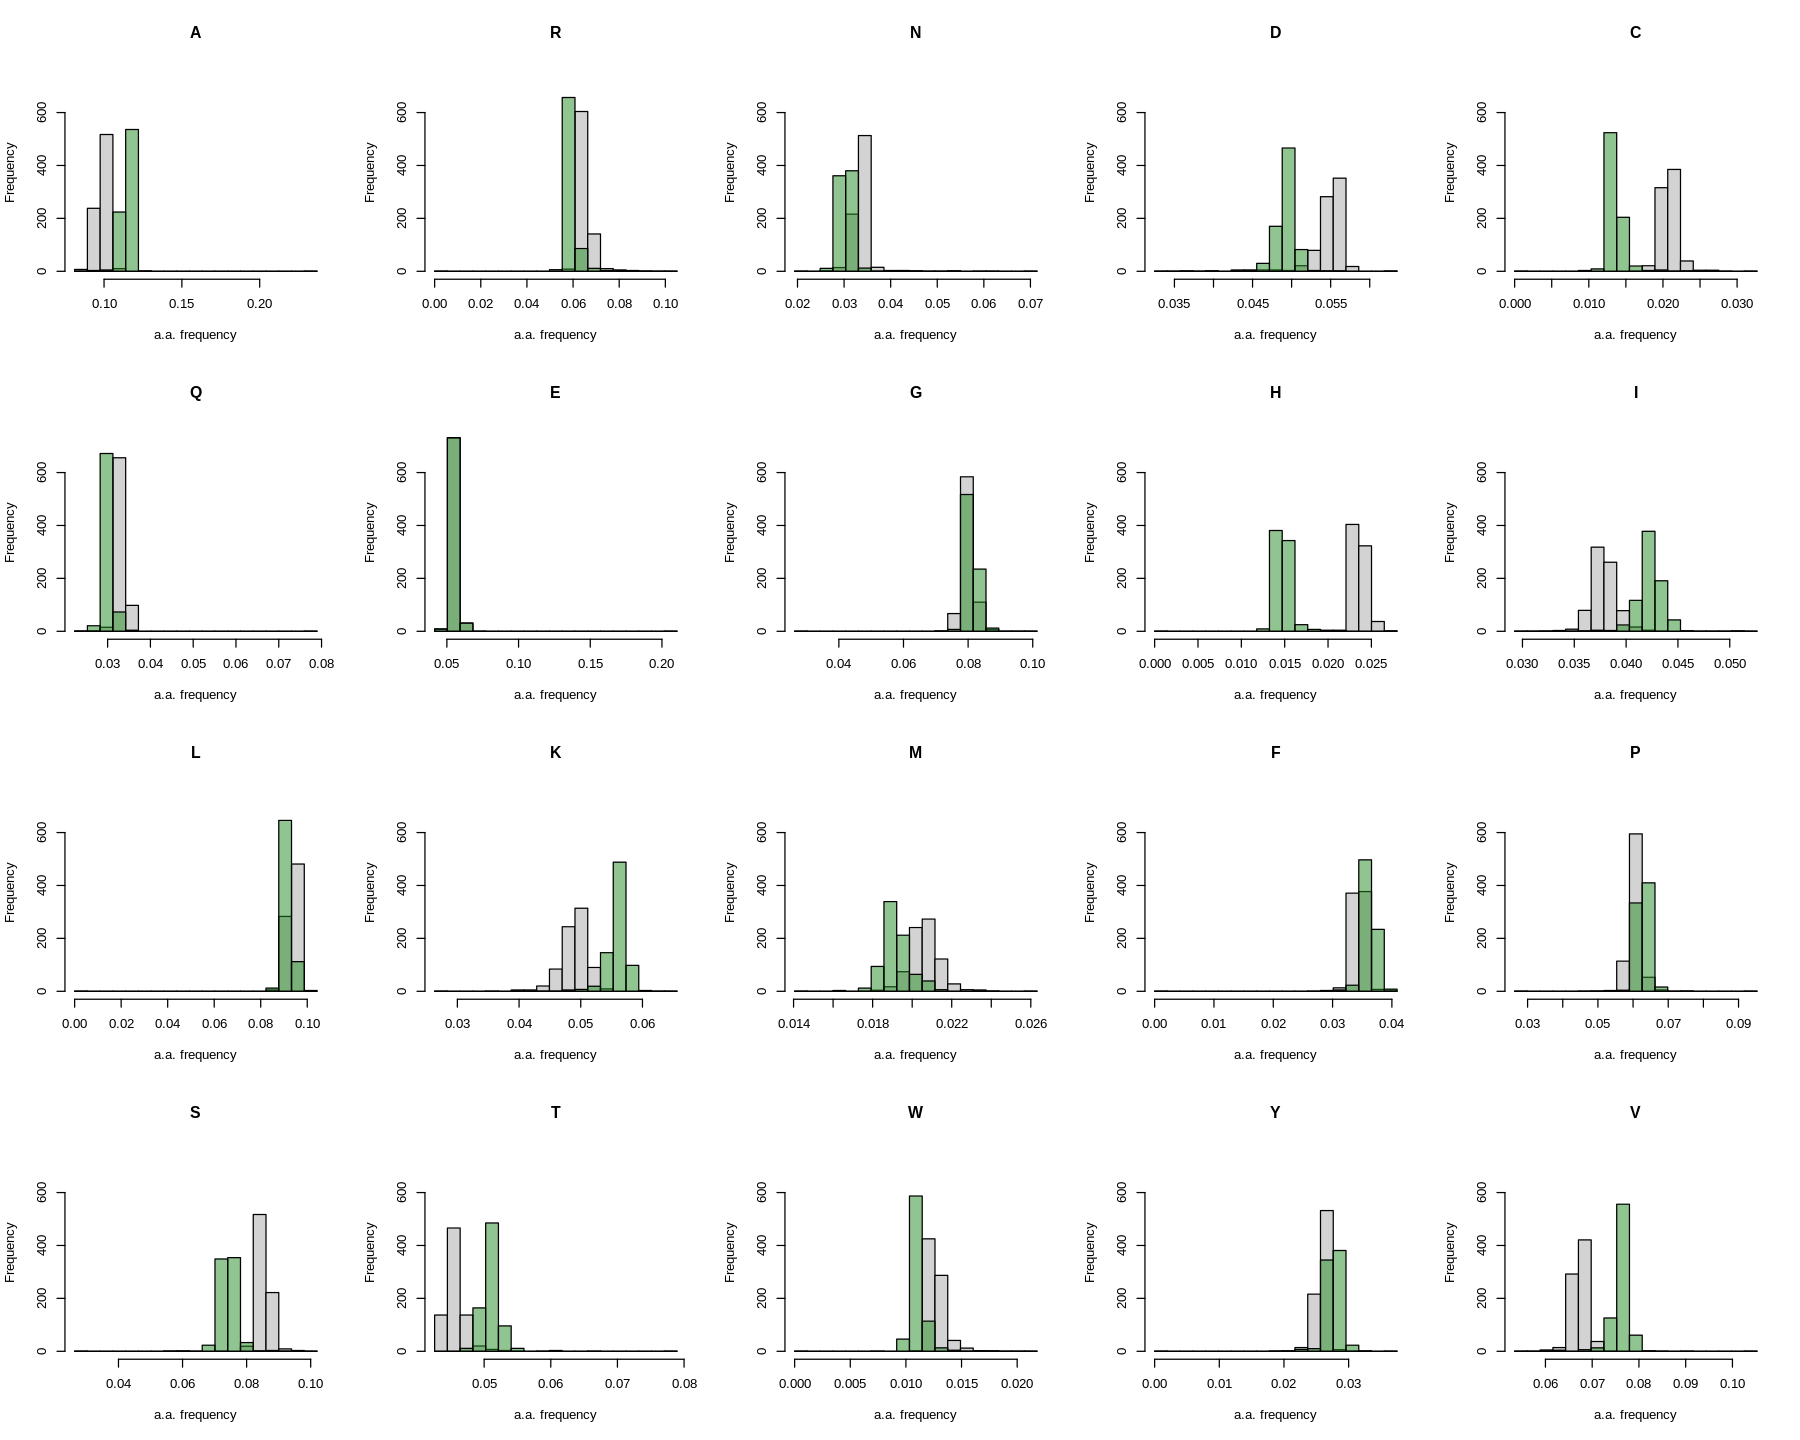

In [173]:
options(repr.plot.width=15, repr.plot.height=12)
par(mfrow = c(4,5))
for(i in 1:20){
    hist(aa.comp.random[,i],main = AA_STANDARD[i],xlab = "a.a. frequency",ylim = c(0,750),
         breaks = seq(min(c(aa.comp.random[,i],aa.comp.photo[,i])),max(c(aa.comp.random[,i],aa.comp.photo[,i])),length.out = 20))
    hist(aa.comp.photo[,i],main = AA_STANDARD[i],add =T,col = scales::alpha("forestgreen",0.5),
         breaks = seq(min(c(aa.comp.random[,i],aa.comp.photo[,i])),max(c(aa.comp.random[,i],aa.comp.photo[,i])),length.out = 20))
}

In [106]:
dat = merge(envDf,TABASCO,by = "assemblyID")

In [107]:
dat$compdup = dat$complete + dat$duplicated

In [108]:
rownames(dat) = dat$assemblyID

In [109]:
dat$pacbio = as.factor(grepl("pacbio",dat$technology,ignore.case = T))

In [110]:
dat1 = cbind(dat[commonID,],PCA.aa.comp$x[,1:3],NperAA[commonID])

In [111]:
colnames(dat1)[ncol(dat1)] = "NperAA"

In [112]:
dat2 = cbind(dat[intersect(commonID,rownames(aa.comp.photo)),],PCA.aa.comp.photo$x[,1:3])

In [140]:
dat3 = cbind(dat[intersect(commonID,rownames(aa.comp.photo)),],aa.comp.photo[intersect(commonID,rownames(aa.comp.photo)),])

In [39]:
fit_model <- function(data, Kmat,responseVar) {
#   library(asreml)
    gc()
    asreml.options(verbose = FALSE)
    tmp = data
    fullFM = as.formula(paste0(responseVar, "~ PC1 + PC2 + PC3 + compdup + pacbio"))
    reducedFM = as.formula(paste0(responseVar, "~ compdup + pacbio"))

    model_full <- asreml(fixed = fullFM,
                         random = ~ vm(assemblyID, Kmat) , ai.sing = F, data = data)
#     model_reduced1 <- asreml(fixed = fullFM,
#                              ai.sing = F, data = data)
    data <- tmp
    model_reduced2 <- asreml(fixed = reducedFM,
                             random = ~ vm(assemblyID, Kmat) , ai.sing = F, data = data)  
    
    totalVar = var(data[,responseVar])
    modelSummary <- summary(model_full)
    IC_full = infoCriteria(model_full,IClikelihood = "full")
    IC_reduced = infoCriteria(model_reduced2,IClikelihood = "full")
    logLik_full <- IC_full$loglik
    logLik_reduced <- IC_reduced$loglik
    BIC_full <- IC_full$BIC
    BIC_reduced <- IC_reduced$BIC

    LRT_statistic <- -2 * (logLik_reduced - logLik_full)
    p_value <- pchisq(LRT_statistic, df = 3, lower.tail = FALSE)
#     gene_explained <-  (model_reduced2$sigma2-model_full$sigma2)/totalVar
#     phylo_explained <- (model_reduced1$sigma2-model_full$sigma2)/totalVar
  
    modelWald <- wald.asreml(model_full)
    partialCoeff <- model_full$coefficients$fixed[2:4]
    partialPval <- modelWald[2:4,4]

#     return(model_full)
    out = c(BIC_full,BIC_reduced,LRT_statistic,p_value,partialCoeff,partialPval)
    names(out) = c("BIC_full","BIC_reduced","LR","p",
                   paste("partialCoeff",c("PC1","PC2","PC3"),sep = "_"),
                   paste("partialP",c("PC1","PC2","PC3"),sep = "_"))
    if(model_full$converge) return(out)
    else return(NULL)
}

In [149]:
fit_model_aa <- function(data, Kmat,responseVar) {
#   library(asreml)
    gc()
    asreml.options(verbose = FALSE)
    tmp = data
    fullFM = as.formula(paste0(responseVar, "~",paste(AA_STANDARD,collapse = "+"),"+ compdup + pacbio"))
    reducedFM = as.formula(paste0(responseVar, "~ compdup + pacbio"))

    model_full <- asreml(fixed = fullFM,
                         random = ~ vm(assemblyID, Kmat) , ai.sing = F, data = data)
#     model_reduced1 <- asreml(fixed = fullFM,
#                              ai.sing = F, data = data)
    data <- tmp
    model_reduced2 <- asreml(fixed = reducedFM,
                             random = ~ vm(assemblyID, Kmat) , ai.sing = F, data = data)  
    
    totalVar = var(data[,responseVar])
    modelSummary <- summary(model_full)
    IC_full = infoCriteria(model_full,IClikelihood = "full")
    IC_reduced = infoCriteria(model_reduced2,IClikelihood = "full")
    logLik_full <- IC_full$loglik
    logLik_reduced <- IC_reduced$loglik
    BIC_full <- IC_full$BIC
    BIC_reduced <- IC_reduced$BIC

    LRT_statistic <- -2 * (logLik_reduced - logLik_full)
    p_value <- pchisq(LRT_statistic, df = 20, lower.tail = FALSE)
#     gene_explained <-  (model_reduced2$sigma2-model_full$sigma2)/totalVar
#     phylo_explained <- (model_reduced1$sigma2-model_full$sigma2)/totalVar
  
#     modelWald <- wald.asreml(model_full)
#     partialCoeff <- model_full$coefficients$fixed[2:4]
#     partialPval <- modelWald[2:4,4]

#     return(model_full)
    out = c(BIC_full,BIC_reduced,LRT_statistic,p_value)
    names(out) = c("BIC_full","BIC_reduced","LR","p")
    if(model_full$converge) return(out)
    else return(NULL)
}

In [42]:
fit_model(dat,phyloKMat,"envPC_1")

ASReml Version 4.2 19/02/2025 15:27:37
          LogLik        Sigma2     DF     wall
 1     -222.9019     0.6278353    753   15:27:37
 2     -203.5751     0.5853925    753   15:27:37
 3     -173.0121     0.5159804    753   15:27:37
 4     -137.5814     0.4301423    753   15:27:38
 5     -109.2145     0.3477457    753   15:27:38
 6     -97.63279     0.2968104    753   15:27:38
 7     -94.36592     0.2694257    753   15:27:38
 8     -93.72561     0.2569776    753   15:27:38
 9     -93.63344     0.2521671    753   15:27:38
10     -93.62246     0.2504928    753   15:27:38
11     -93.62126     0.2499372    753   15:27:39
ASReml Version 4.2 19/02/2025 15:27:39
          LogLik        Sigma2     DF     wall
 1     -231.8192     0.6268451    756   15:27:39
 2     -212.5586     0.5846600    756   15:27:39
 3     -182.0057     0.5154611    756   15:27:39
 4     -146.6320     0.4299741    756   15:27:39
 5     -118.4470     0.3481325    756   15:27:40
 6     -107.0127     0.2976420    756   15:2

BIC_full      BIC_reduced               LR                p 
    226.76824458     210.99152889       4.11928964       0.24886777 
partialCoeff_PC1 partialCoeff_PC2 partialCoeff_PC3     partialP_PC1 
    -11.28320473      -4.49040128      -0.56666741       0.04180881 
    partialP_PC2     partialP_PC3 
      0.93142275       0.44351939

In [43]:
test = mclapply(c(paste("envPC",1:10,sep = "_"),"TN1_GSDE_5_quan50","TC1_GSDE_5_quan50","bio08_Mean_Temperature_Wettest_Quarter_quan50"),
                function(x) fit_model(dat,phyloKMat,x),mc.cores = 13)

In [44]:
test = t(simplify2array(test))
test = as.data.frame(test)
rownames(test) = c(paste("envPC",1:10,sep = "_"),"TN1_GSDE_5_quan50","TC1_GSDE_5_quan50","bio08_Mean_Temperature_Wettest_Quarter_quan50")

In [45]:
test

,BIC_full,BIC_reduced,LR,p,partialCoeff_PC1,partialCoeff_PC2,partialCoeff_PC3,partialP_PC1,partialP_PC2,partialP_PC3
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
envPC_1,226.7682,210.9915,4.1192896,0.24886777,-11.283205,-4.490401,-0.5666674,0.04180881,0.931422749,0.44351939
envPC_2,532.0288,513.0055,0.8726753,0.83201638,1.529384,-10.309147,-12.7489577,0.80829662,0.498449500,0.07941615
envPC_3,696.0664,680.7954,4.6249700,0.20141046,-8.425128,-24.179713,-38.9338791,0.33095828,0.223038256,0.54476943
envPC_4,715.8694,697.1611,1.1877182,0.75595148,-2.259012,-10.140266,31.9677315,0.74348912,0.644020111,0.96165998
envPC_5,637.8562,621.0057,3.0454466,0.38467115,10.189764,15.839769,5.3499232,0.20942366,0.211986470,0.53577352
envPC_6,615.9288,597.3869,1.3540832,0.71633228,-8.195493,-5.553488,7.8449222,0.30008321,0.555569885,0.67356429
envPC_7,759.8025,742.3568,2.4502627,0.48434682,-4.456849,18.290715,33.2141398,0.58691383,0.432798221,0.88287512
envPC_8,497.3883,485.2847,7.7923792,0.05050326,12.966614,18.022320,-53.8050872,0.07259020,0.079857574,0.77095630
envPC_9,733.1776,716.4251,3.1435357,0.37001984,7.087818,20.075004,37.6406570,0.39953819,0.287844199,0.02484160


In [116]:
test2 = mclapply(c(paste("envPC",1:10,sep = "_"),"TN1_GSDE_5_quan50","TC1_GSDE_5_quan50","bio08_Mean_Temperature_Wettest_Quarter_quan50"),
                function(x) fit_model(dat2,phyloKMat,x),mc.cores = 5)

In [118]:
test2 = t(simplify2array(test2))
test2 = as.data.frame(test2)
rownames(test2) = c(paste("envPC",1:10,sep = "_"),"TN1_GSDE_5_quan50","TC1_GSDE_5_quan50","bio08_Mean_Temperature_Wettest_Quarter_quan50")

In [119]:
test2

,BIC_full,BIC_reduced,LR,p,partialCoeff_PC1,partialCoeff_PC2,partialCoeff_PC3,partialP_PC1,partialP_PC2,partialP_PC3
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
envPC_1,211.7811,192.7735,0.7756726,0.85527653,-1.6493026,1.9339826,2.918198,0.348652006,0.5484119,0.767839297
envPC_2,508.4591,491.5247,2.8489194,0.41551009,2.2829987,-7.9448753,-5.636906,0.626254737,0.1117102,0.474127107
envPC_3,677.8499,666.6519,8.5852582,0.03534489,-0.4341589,6.9159074,32.338133,0.993443928,0.0478634,0.003508563
envPC_4,707.1478,689.0714,1.7068296,0.63541648,1.6571049,6.7802588,8.800519,0.780395752,0.2298793,0.511897749
envPC_5,621.3636,603.1870,1.6066361,0.65788606,-2.8297279,-2.6502016,-8.821729,0.444050502,0.8536810,0.526228277
envPC_6,606.9488,589.3678,2.2022963,0.53149622,-1.1134781,6.5359726,-11.266503,0.753330075,0.3580574,0.324651672
envPC_7,745.1529,728.1460,2.7764298,0.42739470,-0.1821101,-1.7481613,-20.598288,0.995415450,0.3539564,0.081431495
envPC_8,487.7730,472.4407,4.4509368,0.21670859,-5.8062700,0.9557656,-6.777266,0.054393816,0.6606769,0.608717230
envPC_9,720.6124,702.2882,1.4589967,0.69176568,0.6183249,-4.4799328,-12.332422,0.531472295,0.6537543,0.475360840


In [150]:
test3 = mclapply(c(paste("envPC",1:10,sep = "_"),"TN1_GSDE_5_quan50","TC1_GSDE_5_quan50","bio08_Mean_Temperature_Wettest_Quarter_quan50"),
                function(x) fit_model_aa(dat3,phyloKMat,x),mc.cores = 5)

In [151]:
test3[[1]]

BIC_full BIC_reduced          LR           p 
303.1752323 192.7735026  14.8921261   0.7825465

In [152]:
test3 = t(simplify2array(test3))
test3 = as.data.frame(test3)
rownames(test3) = c(paste("envPC",1:10,sep = "_"),"TN1_GSDE_5_quan50","TC1_GSDE_5_quan50","bio08_Mean_Temperature_Wettest_Quarter_quan50")


	Pearson's product-moment correlation

data:  -log10(test[, 4]) and -log10(test2[, 4])
t = 1.6451, df = 11, p-value = 0.1282
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.1411999  0.7995777
sample estimates:
      cor 
0.4443559 


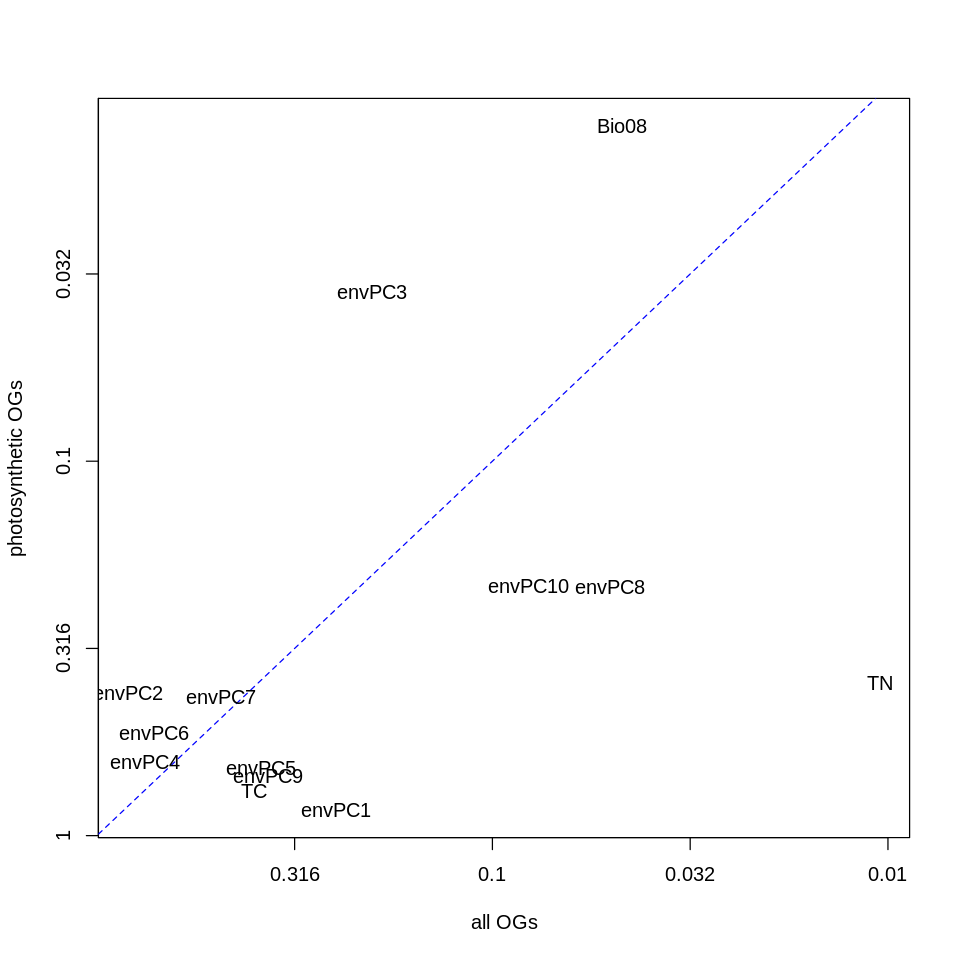

In [138]:
options(repr.plot.width=8, repr.plot.height=8)
plot(-log10(test[,4]),-log10(test2[,4]),xlab = "all OGs",ylab = "photosynthetic OGs",type = 'n',xaxt = "n",yaxt= "n")
axis(1,at = seq(0,2,0.5),labels = round(10^(-seq(0,2,0.5)),3))
axis(2,at = seq(0,2,0.5),labels = round(10^(-seq(0,2,0.5)),3))
abline(a= 0,b= 1,col = "blue",lty =2)
text(-log10(test[,4]),-log10(test2[,4]),labels = c(paste0("envPC",1:10),"TN","TC","Bio08"))
cor.test(-log10(test[,4]),-log10(test2[,4]))


	Pearson's product-moment correlation

data:  -log10(test2[, 4]) and -log10(test3[, 4])
t = 3.0162, df = 11, p-value = 0.01173
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.1935836 0.8928182
sample estimates:
      cor 
0.6728063 


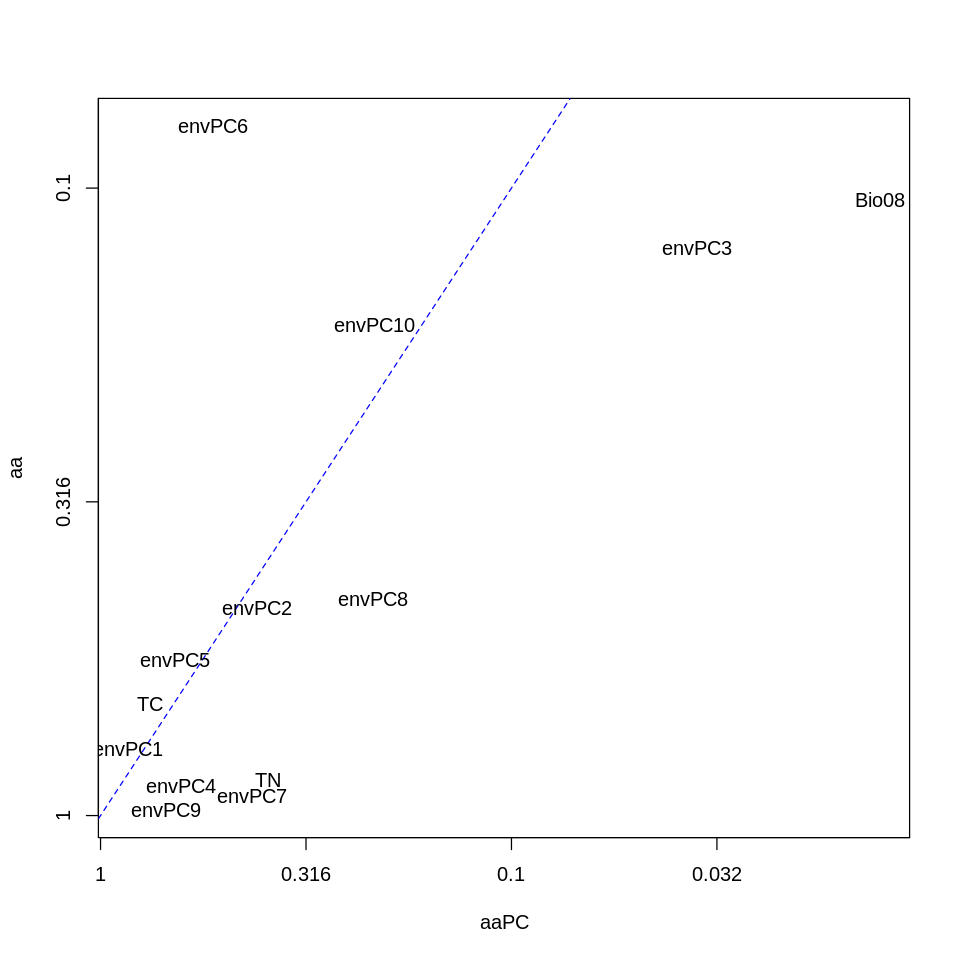

In [153]:
options(repr.plot.width=8, repr.plot.height=8)
plot(-log10(test2[,4]),-log10(test3[,4]),xlab = "aaPC",ylab = "aa",type = 'n',xaxt = "n",yaxt= "n")
axis(1,at = seq(0,2,0.5),labels = round(10^(-seq(0,2,0.5)),3))
axis(2,at = seq(0,2,0.5),labels = round(10^(-seq(0,2,0.5)),3))
abline(a= 0,b= 1,col = "blue",lty =2)
text(-log10(test2[,4]),-log10(test3[,4]),labels = c(paste0("envPC",1:10),"TN","TC","Bio08"))
cor.test(-log10(test2[,4]),-log10(test3[,4]))

[1] 0.7569664

[1] -0.05179215

[1] -0.2310727

[1] -0.1011625

[1] 0.2845143

[1] 0.1398712

[1] 0.07699443

[1] 0.3363904

[1] -0.08382677

[1] -0.01414988

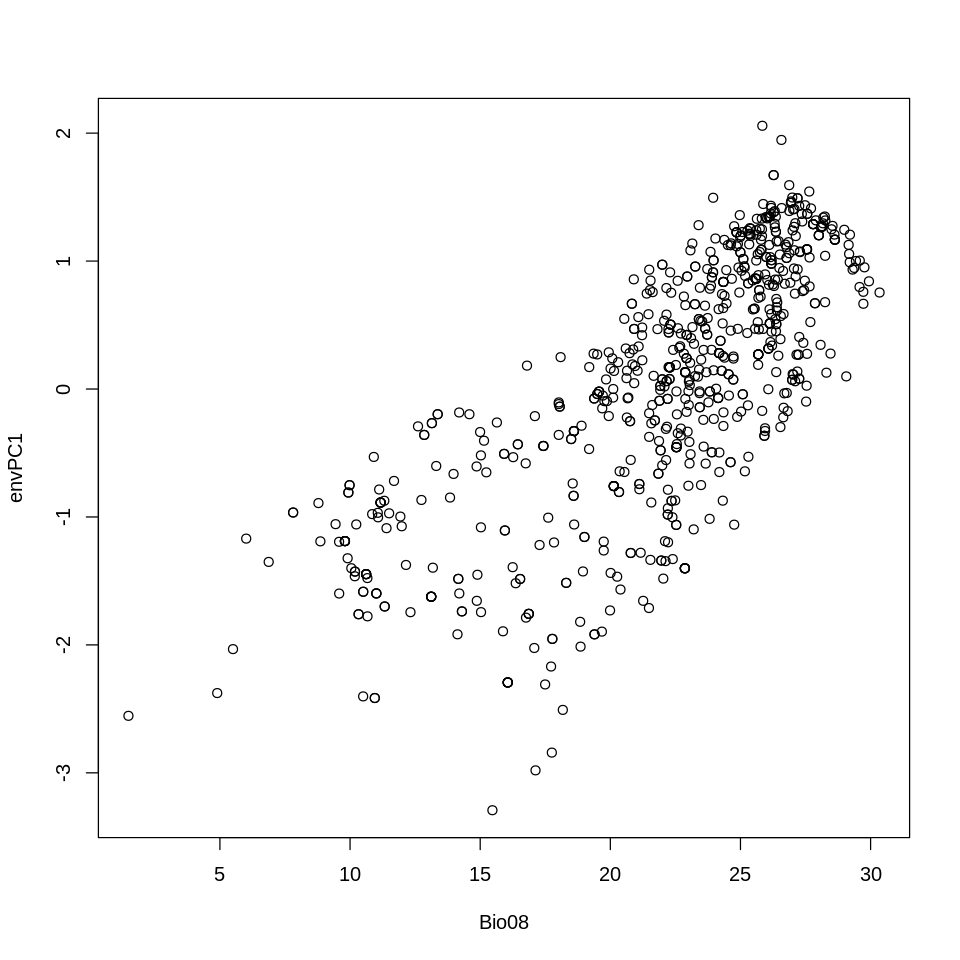

In [158]:
cor(dat2$bio08_Mean_Temperature_Wettest_Quarter_quan50,dat2$envPC_1)
cor(dat2$bio08_Mean_Temperature_Wettest_Quarter_quan50,dat2$envPC_2)
cor(dat2$bio08_Mean_Temperature_Wettest_Quarter_quan50,dat2$envPC_3)
cor(dat2$bio08_Mean_Temperature_Wettest_Quarter_quan50,dat2$envPC_4)
cor(dat2$bio08_Mean_Temperature_Wettest_Quarter_quan50,dat2$envPC_5)
cor(dat2$bio08_Mean_Temperature_Wettest_Quarter_quan50,dat2$envPC_6)
cor(dat2$bio08_Mean_Temperature_Wettest_Quarter_quan50,dat2$envPC_7)
cor(dat2$bio08_Mean_Temperature_Wettest_Quarter_quan50,dat2$envPC_8)
cor(dat2$bio08_Mean_Temperature_Wettest_Quarter_quan50,dat2$envPC_9)
cor(dat2$bio08_Mean_Temperature_Wettest_Quarter_quan50,dat2$envPC_10)
plot(dat2$bio08_Mean_Temperature_Wettest_Quarter_quan50,dat2$envPC_1,xlab = "Bio08",ylab = "envPC1")

In [283]:
fit_model_N <- function(data, Kmat,responseVar) {
#   library(asreml)
    gc()
    asreml.options(verbose = FALSE)
    tmp = data
    fullFM = as.formula(paste0(responseVar, "~ NperAA + compdup + pacbio"))
    reducedFM = as.formula(paste0(responseVar, "~ compdup + pacbio"))

    model_full <- asreml(fixed = fullFM,
                         random = ~ vm(assemblyID, Kmat) , ai.sing = F, data = data)
#     model_reduced1 <- asreml(fixed = fullFM,
#                              ai.sing = F, data = data)
    data <- tmp
    model_reduced2 <- asreml(fixed = reducedFM,
                             random = ~ vm(assemblyID, Kmat) , ai.sing = F, data = data)  
    
    totalVar = var(data[,responseVar])
    modelSummary <- summary(model_full)
    IC_full = infoCriteria(model_full,IClikelihood = "full")
    IC_reduced = infoCriteria(model_reduced2,IClikelihood = "full")
    logLik_full <- IC_full$loglik
    logLik_reduced <- IC_reduced$loglik
    BIC_full <- IC_full$BIC
    BIC_reduced <- IC_reduced$BIC

    LRT_statistic <- -2 * (logLik_reduced - logLik_full)
    p_value <- pchisq(LRT_statistic, df = 1, lower.tail = FALSE)
#     gene_explained <-  (model_reduced2$sigma2-model_full$sigma2)/totalVar
#     phylo_explained <- (model_reduced1$sigma2-model_full$sigma2)/totalVar
  
    modelWald <- wald.asreml(model_full)
    partialCoeff <- model_full$coefficients$fixed[2]
    partialPval <- modelWald[2,4]

#     return(model_full)
    out = c(BIC_full,BIC_reduced,LRT_statistic,p_value,partialCoeff,partialPval)
    names(out) = c("BIC_full","BIC_reduced","LR","p",
                   paste("partialCoeff",c("NperAA"),sep = "_"),
                   paste("partialP",c("NperAA"),sep = "_"))
    if(model_full$converge) return(out)
    else return(NULL)
}

Warning message in cor.test.default(dat$PC1, dat$NperAA, method = "spearman"):
“Cannot compute exact p-value with ties”



	Spearman's rank correlation rho

data:  dat$PC1 and dat$NperAA
S = 15232184, p-value < 2.2e-16
alternative hypothesis: true rho is not equal to 0
sample estimates:
      rho 
0.7909795 


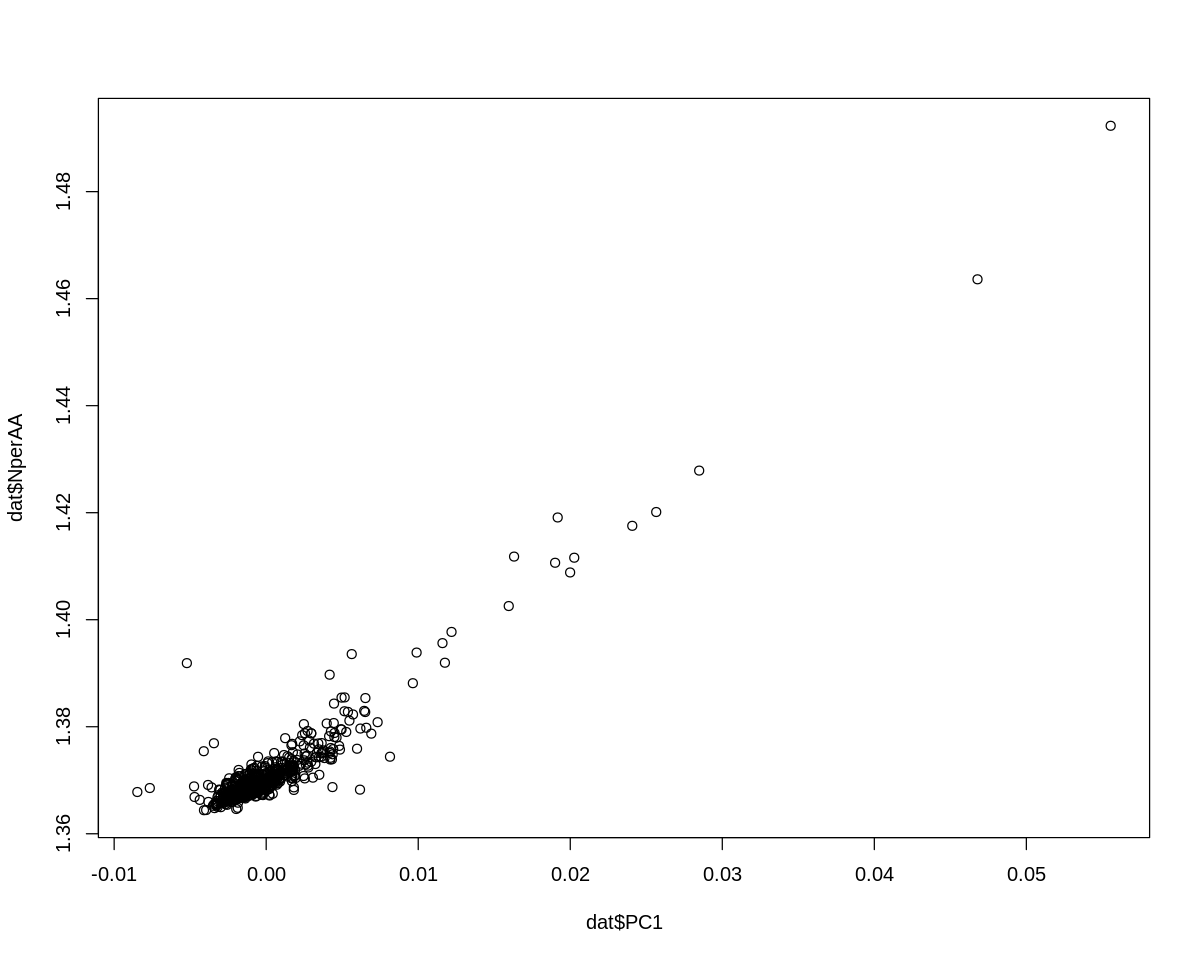

In [260]:
plot(dat$PC1,dat$NperAA)
cor.test(dat$PC1,dat$NperAA,method = "spearman")

In [284]:
fit_model_N(dat,phyloKMat,'TN1_GSDE_5_quan50')

ASReml Version 4.2 18/02/2025 15:45:43
          LogLik        Sigma2     DF     wall
 1     -1539.613      20.12613    755   15:45:43
 2     -1533.639      19.49397    755   15:45:43
 3     -1526.751      18.58867    755   15:45:43
 4     -1522.205      17.68310    755   15:45:44
 5     -1520.449      16.94531    755   15:45:44
 6     -1520.275      16.68247    755   15:45:44
 7     -1520.270      16.63368    755   15:45:44
ASReml Version 4.2 18/02/2025 15:45:44
          LogLik        Sigma2     DF     wall
 1     -1543.179      20.12875    756   15:45:44
 2     -1537.226      19.49824    756   15:45:44
 3     -1530.342      18.59328    756   15:45:45
 4     -1525.777      17.68534    756   15:45:45
 5     -1523.999      16.94296    756   15:45:45
 6     -1523.818      16.67594    756   15:45:45
 7     -1523.813      16.62540    756   15:45:45


BIC_full         BIC_reduced                  LR                   p 
       3069.1178838        3063.5853155           1.0994334           0.2943905 
partialCoeff_NperAA     partialP_NperAA 
         20.9297950           0.2394237

In [296]:
dat[dat$assemblyID%in%names(which(PCA.aa.comp$x[,1]>0.01)),]